# How to sample from a mesh?

In [ ]:
import sys
from pathlib import Path

import geomfum
from geomfum.dataset import NotebooksDataset
from geomfum.metric import HeatDistanceMetric
from geomfum.metric.mesh import (
    GraphShortestPathMetric,
    VertexEuclideanMetric,
)
from geomfum.sample import FarthestPointSampler, PoissonSampler, VertexProjectionSampler
from geomfum.shape import TriangleMesh

notebooks_dir = Path(geomfum.__file__).resolve().parents[1] / "notebooks"
notebooks_dir_str = str(notebooks_dir)
if notebooks_dir_str not in sys.path:
    sys.path.insert(0, notebooks_dir_str)

from plot_utils import setup_pyvista, show_mesh_with_highlights  # noqa: E402

setup_pyvista()


In [2]:
dataset = NotebooksDataset()
mesh = TriangleMesh.from_file(dataset.get_filename("cat-00"))

## "Coordinate" samplers

If we're interested in sampling coordinates of points on the mesh, we can use `PoissonSampler`.


In [3]:
poisson_sampler = PoissonSampler.from_registry(min_n_samples=3, which="pymeshlab")
sampled_vertices = poisson_sampler.sample(mesh)
sampled_vertices

array([[-0.04288694,  0.37403726,  0.28778169],
       [ 0.03607215,  0.05786218, -0.10858711],
       [-0.04039455,  0.00925685,  0.18873429],
       [ 0.00951004,  0.25221589, -0.43900669],
       [-0.00933553,  0.33280937, -0.01679519]])

## Vertex indices samplers

If we're interested in sampling vertex indices instead, we can leverage "coordinate" samplers like `PoissonSampler` by projecting the coordinates to the closest vertices.

In [4]:
vertex_sampler = VertexProjectionSampler(sampler=poisson_sampler)
sampled_indices = vertex_sampler.sample(mesh)
sampled_indices.astype(int)

array([5618, 2377, 4360, 7137,  105,  588])

To get vertex coordinates.

In [5]:
sampled_vertices = mesh.vertices[sampled_indices]
sampled_vertices

array([[ 0.052266,  0.01949 , -0.08939 ],
       [-0.057531,  0.038724,  0.152556],
       [ 0.007673,  0.273714,  0.332385],
       [ 0.008992,  0.253917, -0.39041 ],
       [ 0.053982,  0.263046, -0.139122],
       [-0.026358,  0.318528,  0.094601]])

Let's visualize the sampled points

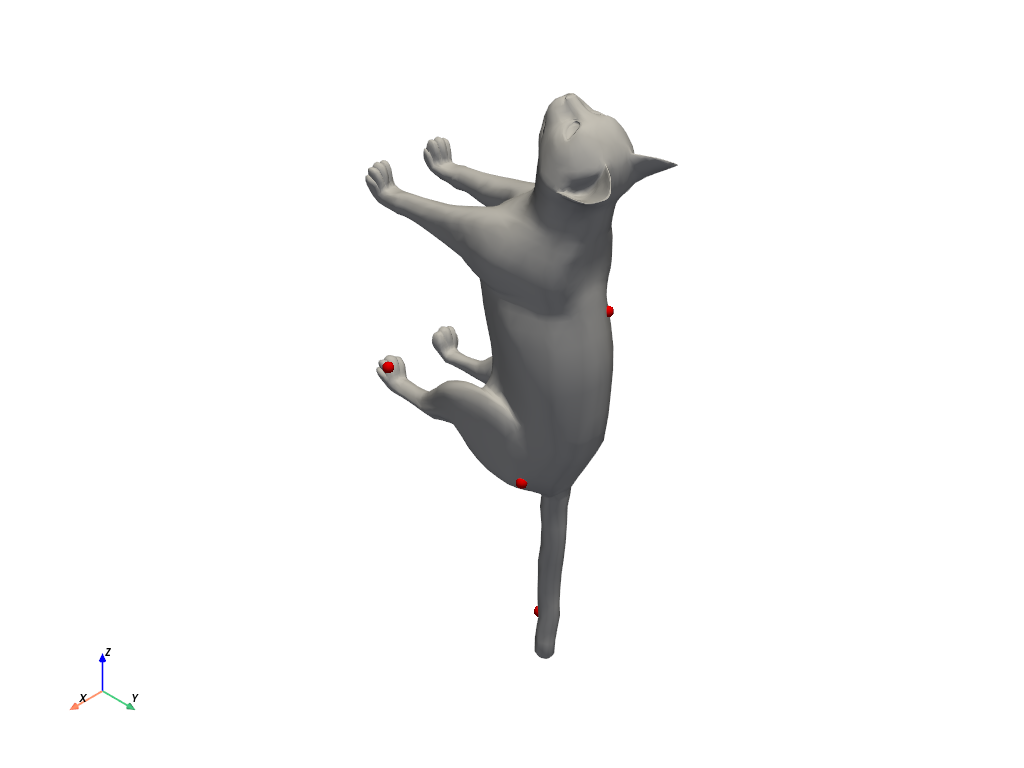

In [6]:
show_mesh_with_highlights(mesh.vertices, mesh.faces, sampled_vertices)


## Farthest point sampler

Alternatively, we can sample vertex indices directly with `FarthestPointSampler`. 

Select the metrics.

In [7]:
metrics = {
    "euclidean": VertexEuclideanMetric,
    "heat-distance": HeatDistanceMetric,
    "graph": GraphShortestPathMetric,
}

The vertex **7181** corresponds to the extreme of the cat’s tail. We start to sample from this point.


In [8]:
fps = {}
samp = FarthestPointSampler(
    6,
)

for name, metric in metrics.items():
    mesh.equip_with_metric(metric)
    samples = samp.sample(mesh, first_point=7181)
    fps[name] = samples
    print(f"FPS {name}: {samples}")


FPS euclidean: [7181 4260 6811  404 1625 7080]
FPS heat-distance: [7181 3026 6868 3844 5951 1817]
FPS graph: [7181 4078 5972 7005 1921  402]


Let's visualize the sampled points

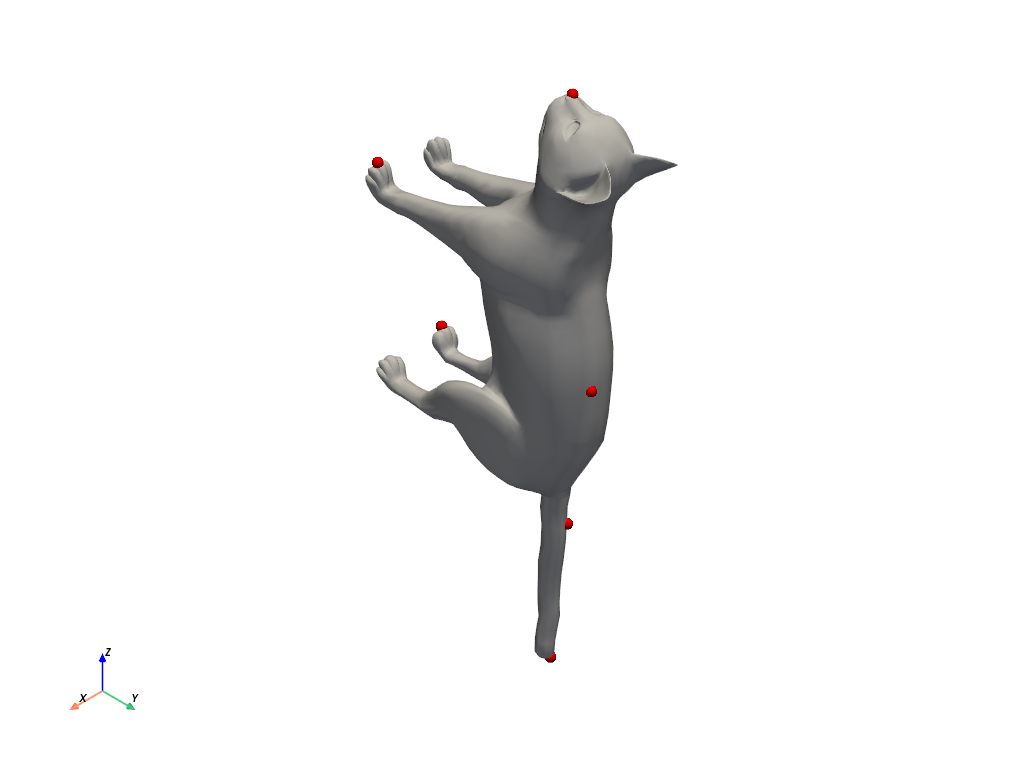

In [9]:
show_mesh_with_highlights(mesh.vertices, mesh.faces, mesh.vertices[fps["euclidean"]])


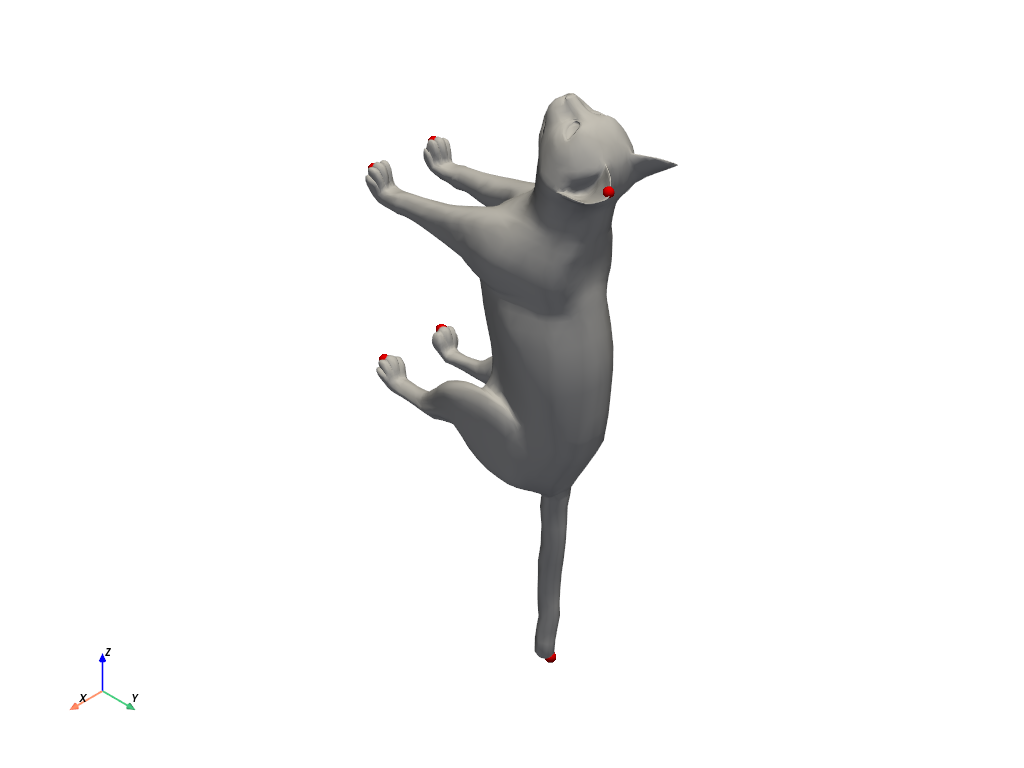

In [10]:
show_mesh_with_highlights(
    mesh.vertices, mesh.faces, mesh.vertices[fps["heat-distance"]]
)


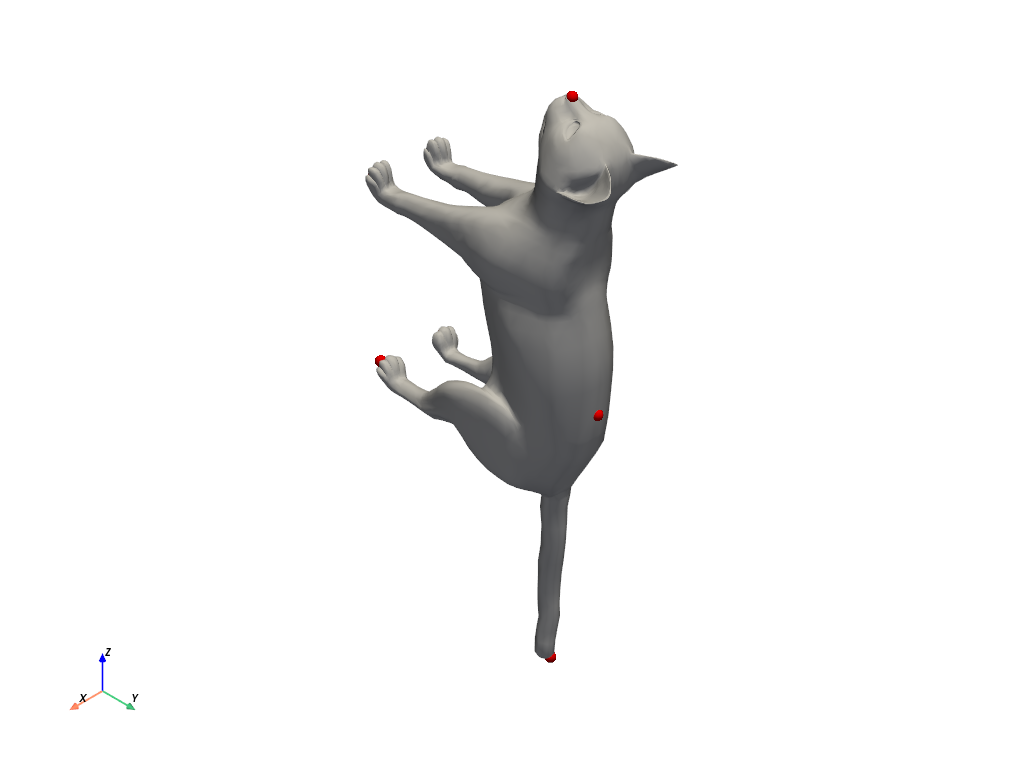

In [11]:
show_mesh_with_highlights(mesh.vertices, mesh.faces, mesh.vertices[fps["graph"]])


### Sampling from a subset

The vertex **4265** corresponds to the extreme of the cat’s muzzle, i want to select the FPs on the tail.

In [12]:
points_on_the_tail = list(range(len(mesh.vertices) - 100, len(mesh.vertices)))

In [13]:
fps = {}
dataset = NotebooksDataset()
samp = FarthestPointSampler(
    6,
)
for name, metric in metrics.items():
    mesh.equip_with_metric(metric)
    samples = samp.sample(mesh, points_pool=points_on_the_tail, first_point=4265)
    fps[name] = samples
    print(f"FPS {name}: {samples}")

C:\Users\giuli\OneDrive\Research\geomfum_proj\geomfum\geomfum\sample.py:76: UserWarning: First index 4265 is not in the points pool [7107 7108 7109 7110 7111 7112 7113 7114 7115 7116 7117 7118 7119 7120
 7121 7122 7123 7124 7125 7126 7127 7128 7129 7130 7131 7132 7133 7134
 7135 7136 7137 7138 7139 7140 7141 7142 7143 7144 7145 7146 7147 7148
 7149 7150 7151 7152 7153 7154 7155 7156 7157 7158 7159 7160 7161 7162
 7163 7164 7165 7166 7167 7168 7169 7170 7171 7172 7173 7174 7175 7176
 7177 7178 7179 7180 7181 7182 7183 7184 7185 7186 7187 7188 7189 7190
 7191 7192 7193 7194 7195 7196 7197 7198 7199 7200 7201 7202 7203 7204
 7205 7206].
  warnings.warn(


FPS euclidean: [4265 7205 7206 7119 7133 7113]
FPS heat-distance: [4265 7178 7206 7119 7133 7108]
FPS graph: [4265 7192 7206 7122 7132 7113]


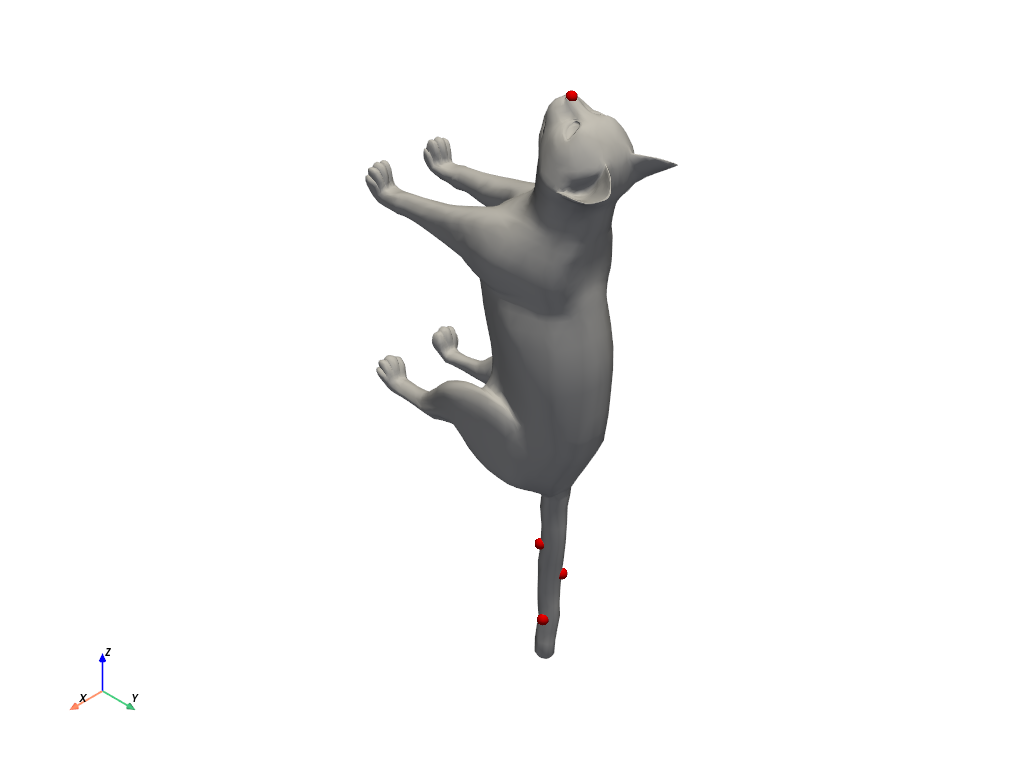

In [14]:
show_mesh_with_highlights(mesh.vertices, mesh.faces, mesh.vertices[fps["euclidean"]])


## Further reading

* [How to compute descriptors?](./03_descriptors.ipynb)

* [How to set landmarks?](./06_landmarks.ipynb)